![Alt](../src/pages/FolioXLab.png)

In [1]:
import yfinance as yf

from datetime import datetime

import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
from matplotlib import cm


import seaborn as sns

In [2]:
equities_df = pd.read_csv('../src/static/data/EQUITY_L.csv')

In [5]:
equities_df

,SYMBOL,NAME OF COMPANY,SERIES,DATE OF LISTING,PAID UP VALUE,MARKET LOT,ISIN NUMBER,FACE VALUE
0,20MICRONS,20 Microns Limited,EQ,06-OCT-2008,5,1,INE144J01027,5
1,21STCENMGM,21st Century Management Services Limited,BE,03-MAY-1995,10,1,INE253B01015,10
2,360ONE,360 ONE WAM LIMITED,EQ,19-SEP-2019,1,1,INE466L01038,1
3,3IINFOLTD,3i Infotech Limited,EQ,22-OCT-2021,10,1,INE748C01038,10
4,3MINDIA,3M India Limited,EQ,13-AUG-2004,10,1,INE470A01017,10
...,...,...,...,...,...,...,...,...
2087,ZOTA,Zota Health Care LImited,EQ,19-AUG-2019,10,1,INE358U01012,10
2088,ZUARI,Zuari Agro Chemicals Limited,EQ,27-NOV-2012,10,1,INE840M01016,10
2089,ZUARIIND,ZUARI INDUSTRIES LIMITED,EQ,12-APR-1995,10,1,INE217A01012,10
2090,ZYDUSLIFE,Zydus Lifesciences Limited,EQ,18-APR-2000,1,1,INE010B01027,1


In [ ]:
# with open('../src/pages/nse_symbols.py', 'w') as f:
#     data = equities_df[equities_df[' SERIES'] == 'EQ'][['NAME OF COMPANY', 'SYMBOL']].to_dict(orient='records') # .value_counts()
#     f.write(f"data = {data}")

In [3]:
def get_historic_df(stock_tickers, period=3*365):
    """
    Fetches historical closing prices of given stock tickers for the last 'period' days.
    
    Parameters:
        stock_tickers (list): List of stock ticker symbols.
        period (int): Number of days of historical data to fetch (default: 3 years).
    
    Returns:
        pd.DataFrame: DataFrame with date as index and stock tickers as columns.
    """
    # Calculate start date based on the given period
    start_date = pd.Timestamp.today() - pd.Timedelta(days=period)
    
    # Download data from Yahoo Finance
    df = yf.download(stock_tickers, start=start_date.strftime('%Y-%m-%d'))["Close"]
    
    return df

In [5]:
stocks = ['SUZLON.NS', 'HDFCBANK.NS', 'IRFC.NS']
stock_qty = [60, 10, 100]

In [6]:
df = get_historic_df(stocks, period=365*3)[stocks]

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  3 of 3 completed


In [7]:
df.shape

(740, 3)

In [8]:
df

Ticker,SUZLON.NS,HDFCBANK.NS,IRFC.NS
Date,,,
2022-03-17,8.952586,1426.965698,20.949129
2022-03-21,8.814854,1433.184204,20.765764
2022-03-22,8.723032,1440.560059,20.490723
2022-03-23,8.677122,1426.194214,20.490723
2022-03-24,8.539389,1390.907104,20.444880
...,...,...,...
2025-03-07,54.919998,1689.250000,123.419998
2025-03-10,53.240002,1687.500000,119.750000
2025-03-11,53.759998,1685.500000,119.300003


In [9]:
# Compute log returns = ln(previous day/current day)
log_returns = np.log(df / df.shift(1)).dropna()

In [10]:
log_returns

Ticker,SUZLON.NS,HDFCBANK.NS,IRFC.NS
Date,,,
2022-03-21,-0.015504,0.004348,-0.008791
2022-03-22,-0.010471,0.005133,-0.013333
2022-03-23,-0.005277,-0.010022,0.000000
2022-03-24,-0.016001,-0.025053,-0.002240
2022-03-25,0.005362,-0.008178,-0.009009
...,...,...,...
2025-03-07,0.052713,-0.001154,0.023197
2025-03-10,-0.031068,-0.001036,-0.030187
2025-03-11,0.009720,-0.001186,-0.003765


<Figure size 640x480 with 0 Axes>

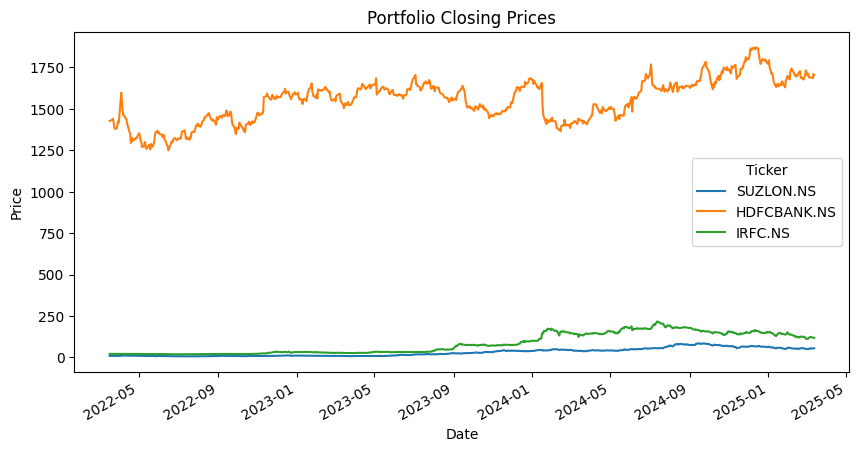

In [11]:
# Plot historical prices
plt.figure();
df.plot(title="Portfolio Closing Prices", figsize=(10,5));
plt.xlabel("Date");
plt.ylabel("Price");
plt.show();


<Figure size 1000x500 with 0 Axes>

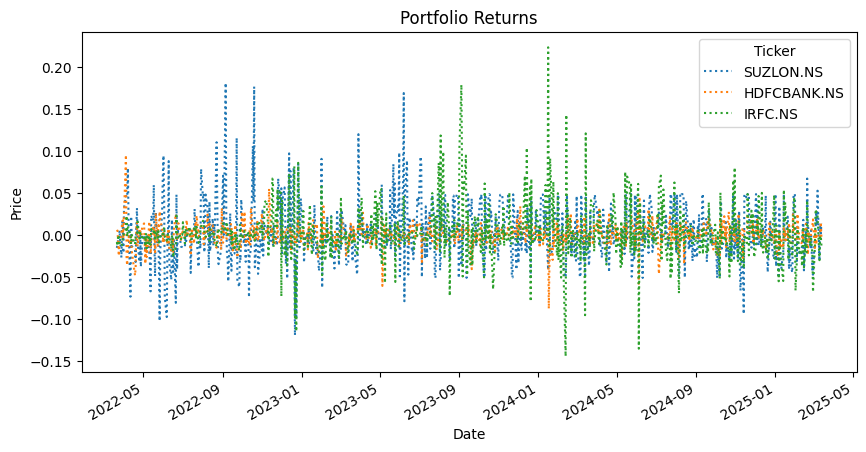

In [12]:
# Plot historical prices
plt.figure(figsize=(10,5));
log_returns.plot(title="Portfolio Returns", 
             figsize=(10,5), ls=':');
# plt.Line2D.set_linestyle(ls='.');
plt.xlabel("Date");
plt.ylabel("Price");
plt.show();


In [ ]:
# Compute statistics
mu = log_returns.mean()
sigma = log_returns.std()
correlation_matrix = log_returns.corr()

# Print results
print("Mean Returns:\n", mu)
print("\nVolatility:\n", sigma)
print("\nCorrelation Matrix:\n", correlation_matrix)


Mean Returns:
 Ticker
SUZLON.NS      0.002446
HDFCBANK.NS    0.000242
IRFC.NS        0.002336
dtype: float64

Volatility:
 Ticker
SUZLON.NS      0.034670
HDFCBANK.NS    0.013227
IRFC.NS        0.029700
dtype: float64

Correlation Matrix:
 Ticker       SUZLON.NS  HDFCBANK.NS   IRFC.NS
Ticker                                       
SUZLON.NS     1.000000     0.133420  0.250958
HDFCBANK.NS   0.133420     1.000000  0.110984
IRFC.NS       0.250958     0.110984  1.000000


In [21]:
qtr_log_returns = np.log(df / df.shift(63)).dropna()
yr_log_returns = np.log(df / df.shift(252)).dropna()

qtr_log_returns.mean()
yr_log_returns.mean()

Ticker
SUZLON.NS      0.999577
HDFCBANK.NS    0.064619
IRFC.NS        0.985603
dtype: float64

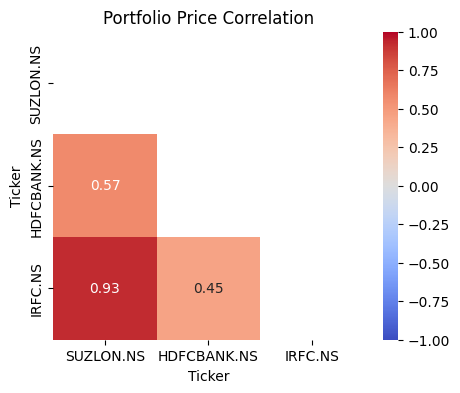

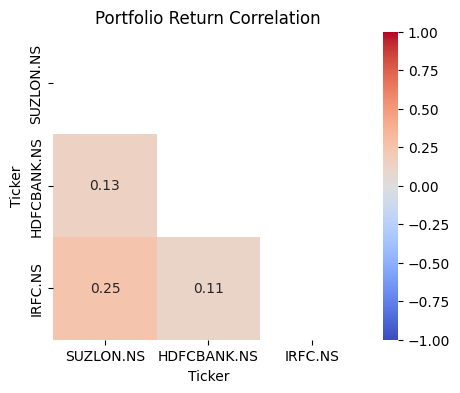

In [20]:
# Getting the Upper Triangle of the co-relation matrix
matrix = np.triu(correlation_matrix)

# Plot heatmap of correlation matrix for gold silver prices
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", mask=matrix, vmin=-1, vmax=1)
plt.title("Portfolio Price Correlation")
plt.show()


# Plot heatmap of correlation matrix gold silver returns
plt.figure(figsize=(5,4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", mask=matrix, vmin=-1, vmax=1)
plt.title("Portfolio Return Correlation")
plt.show()


### Monte Carlo Simulation

In [3]:
def simulate_portfolio(stocks, stock_qty, hist_years=3, T=4*3, dt=30*3, n_sim=10000):
    
    # Get historic data
    df = get_historic_df(stocks, period=365*hist_years)[stocks]

    # Compute log returns = ln(previous day/current day)
    log_returns = np.log(df / df.shift(1)).dropna()

    # Compute statistics
    mu = log_returns.mean()
    sigma = log_returns.std()
    correlation_matrix = log_returns.corr()

    # Monte Carlo simulation
    S0 = df.iloc[-1].values  # Last known prices
    L = np.linalg.cholesky(correlation_matrix.values)  # Cholesky decomposition for correlation

    # Number of stocks in portfolio
    num_stocks = len(df.columns)

    # Initialize paths
    paths = np.zeros((T, num_stocks, n_sim))
    paths[0, :, :] = S0.reshape(-1, 1)

    # Simulate correlated GBM paths
    np.random.seed(42)
    for t in range(1, T):
        Z = np.random.randn(num_stocks, n_sim)  # Independent normal variables
        Z_corr = L @ Z  # Apply correlation
        drift = (mu - 0.5 * sigma**2) * dt
        diffusion = sigma.values[:, None] * np.sqrt(dt) * Z_corr
        paths[t] = paths[t - 1] * np.exp(drift.values[:, None] + diffusion)

    print("Monte Carlo Simulation Completed! ✅")

    # Compute portfolio paths
    portfolio = np.zeros((T, n_sim))


    for n in range(num_stocks):
        portfolio = portfolio + stock_qty[n] * paths[:, n, :]

    portfolio = pd.DataFrame(portfolio)

    return portfolio

    # 0.7 * paths[:, 0, :] + 0.3 * paths[:, 1, :]

In [4]:
stocks = ['HDFCBANK.NS', 'SUZLON.NS']
stock_qty = [1, 1]

In [5]:
portfolio = simulate_portfolio(stocks, stock_qty)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


Monte Carlo Simulation Completed! ✅


In [6]:
portfolio

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,...,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977,1761.179977
1,1903.219728,1766.487922,1940.431752,2176.521991,1782.212105,1737.668644,2215.661048,1966.118550,1686.762037,1947.227789,...,2184.074890,1836.562667,1977.864732,1521.009361,2112.478020,2124.613872,1444.870135,1661.665824,1965.207658,1924.204743
2,2002.551983,1852.644185,1758.859206,2397.155644,1571.241461,1655.184203,1750.325929,2429.998691,1678.951971,2591.774019,...,2280.192368,2380.066852,2263.034313,1331.053939,1831.270061,2067.677614,1778.514604,1621.443835,1648.749013,1917.160386
3,1930.262369,2145.874922,1778.286713,2553.250731,1810.728976,1718.156015,1433.294735,2828.436728,2049.933554,2147.038237,...,2405.646885,2216.860063,2198.588604,1621.831713,1403.758540,2110.498653,1781.808688,1776.540257,1660.439340,2364.087877
4,1997.180103,2384.392301,1864.042392,2409.138354,1869.883158,1917.579498,1525.083474,2611.906553,2198.981017,2404.491442,...,2397.784509,2088.097592,2690.422934,1813.451266,1267.543722,2104.621538,1926.116067,1890.579298,1818.654987,1995.137691
5,2240.254372,2345.454798,1880.895673,2605.472132,1861.702181,1985.714717,1979.941854,2573.339309,2855.783080,1913.717700,...,2606.653760,2483.604930,2653.659855,1948.351238,1123.863239,2677.715920,1805.434126,1900.610644,1921.107534,1994.325294
6,2635.723852,2090.063744,2056.882952,2604.300223,1763.585464,1990.576628,2016.324454,2107.908001,3413.133045,2255.151548,...,3099.928731,2395.434532,2692.519322,2385.564057,954.423681,2339.862006,1835.893454,1973.695049,1746.319795,2256.604350
7,2707.394938,2263.590805,2314.073961,2205.185947,1845.845114,1961.783884,1924.634321,1982.315513,3824.029537,1949.881112,...,2780.838154,2307.203916,2788.924757,2368.811992,916.584526,2087.349965,2343.941201,1908.373175,1764.835118,2598.942170
8,2861.366879,2098.436741,2474.212047,2421.663443,2170.606075,2362.764644,1846.934099,2150.589028,3558.391259,1597.755715,...,3392.740446,2231.922653,3325.026826,2856.327795,917.593081,2497.020646,2562.213489,1891.603064,1839.466209,2962.631712
9,3267.443123,1915.614671,3060.867569,3155.131942,2004.820104,2575.352796,2151.509927,2036.162509,3913.981585,1597.554793,...,3001.599727,2180.795912,3899.180232,3271.301110,1312.823337,2866.776141,2555.985071,1879.980270,1763.796922,2970.476436


In [60]:
# Simulation parameters
T, dt, n_sim = 4 * 3, 30 * 3, 10000  # 3 years, 252 trading days/year, 10000 simulations
S0 = df.iloc[-1].values  # Last known prices
L = np.linalg.cholesky(correlation_matrix.values)  # Cholesky decomposition for correlation

# Number of stocks in portfolio
num_stocks = len(df.columns)

# Initialize paths
paths = np.zeros((T, num_stocks, n_sim))
paths[0, :, :] = S0.reshape(-1, 1)

# Simulate correlated GBM paths
np.random.seed(42)
for t in range(1, T):
    Z = np.random.randn(num_stocks, n_sim)  # Independent normal variables
    Z_corr = L @ Z  # Apply correlation
    drift = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma.values[:, None] * np.sqrt(dt) * Z_corr
    paths[t] = paths[t - 1] * np.exp(drift.values[:, None] + diffusion)

print("Monte Carlo Simulation Completed! ✅")


Monte Carlo Simulation Completed! ✅


In [61]:
paths.shape

(12, 3, 10000)

In [62]:
np.zeros((T, n_sim))

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(12, 10000))

In [64]:
10 * paths[:, 0, :] # + 

array([[  545.80001831,   545.80001831,   545.80001831, ...,
          545.80001831,   545.80001831,   545.80001831],
       [  757.81227175,   615.07193136,   796.36370082, ...,
          510.48834068,   757.57604775,   795.50040998],
       [  466.10760579,   512.8224786 ,   774.36908677, ...,
          737.24542862,  1167.70234822,  1054.58003532],
       ...,
       [ 3192.5403887 , 10170.71759725,   749.8417306 , ...,
         2363.73322307,  2640.80025064,  1534.49537464],
       [ 2946.24323989, 15382.89829925,   768.28568944, ...,
         2451.36141189,  4063.46465937,  1484.61928336],
       [ 2193.25153975, 21720.07951517,   870.7897517 , ...,
         2171.83518507,  4521.40801166,  1970.56782861]],
      shape=(12, 10000))

In [72]:
# Compute portfolio paths
portfolio = np.zeros((T, n_sim))


for n in range(num_stocks):
    portfolio = portfolio + stock_qty[n] * paths[:, n, :]

portfolio = pd.DataFrame(portfolio)

# 0.7 * paths[:, 0, :] + 0.3 * paths[:, 1, :]

In [70]:
portfolio

array([[ 32109.80010986,  32109.80010986,  32109.80010986, ...,
         32109.80010986,  32109.80010986,  32109.80010986],
       [ 36352.36596441,  35261.70203677,  32302.23942161, ...,
         32803.19977695,  35259.13538522,  32408.1292803 ],
       [ 34279.30843437,  38559.91558118,  37203.70531338, ...,
         39466.26757232,  36481.4814468 ,  40831.1144816 ],
       ...,
       [109325.74607126, 145041.03489303,  58313.19474868, ...,
         44537.72998681,  59020.60983918,  63124.25951518],
       [138851.3780967 , 163078.74972971,  74864.41994401, ...,
         44202.46602105,  69008.73264777,  61069.50522183],
       [179773.88007506, 223470.26484503,  79664.44542142, ...,
         51550.17545384,  68624.21498601,  79072.8471185 ]],
      shape=(12, 10000))

In [17]:
y_final_values = paths[[-1]]

In [18]:
y_final_values[:, 0, :]

array([[1779.69596982, 4276.50275469, 1250.12321543, ..., 1773.03114061,
        2346.80732561, 1708.31219474]], shape=(1, 10000))

In [19]:
y_final_values[:, i, :100][0]

array([ 792.59912153,  211.34702963,  253.74369032,  431.24173301,
        453.42941558,  186.85011821, 1091.3672683 , 1973.65747421,
        786.69609382,  485.60459933,  186.02899889,  754.38820625,
        186.98401556,   81.68035143,  217.93558245,   73.59523214,
       3085.05105002,  467.27559958,  173.96974923, 1212.92686727,
       4339.29266692,  763.95330312, 1445.27367485,  135.27584338,
         85.1193667 ,  400.89237739,  564.60278223,  309.30350414,
        171.53748994,  239.1023244 , 1154.81716435, 2954.99902652,
        488.22188785,  159.91550506, 2457.69551952,   70.22507739,
        306.88310584, 1027.60079394,  730.81648416,   97.32585451,
        382.10048144,  115.55885886,   78.65660719,  402.91430319,
       1289.66906947,   59.94813577,  993.2120398 ,  277.59909836,
        275.06279275,  417.60052992,   61.50185179,   35.97189665,
        293.3330323 ,  208.49835242,  197.03511413,  160.6938527 ,
        529.14384423,  118.31679562,  981.08618398, 1672.51545

<Axes: xlabel='Density'>

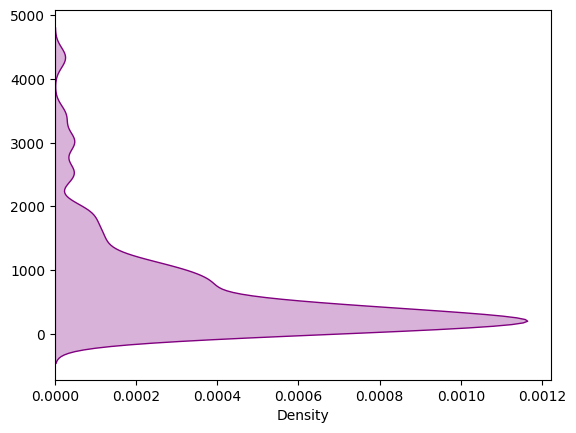

In [20]:
sns.kdeplot(y=y_final_values[:, i, :100][0], color='purple', fill=True, alpha=0.3, bw_adjust=0.5)

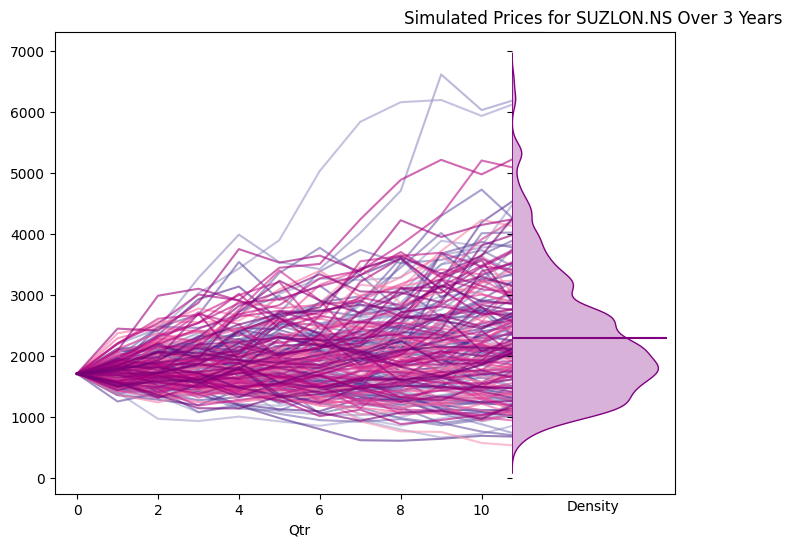

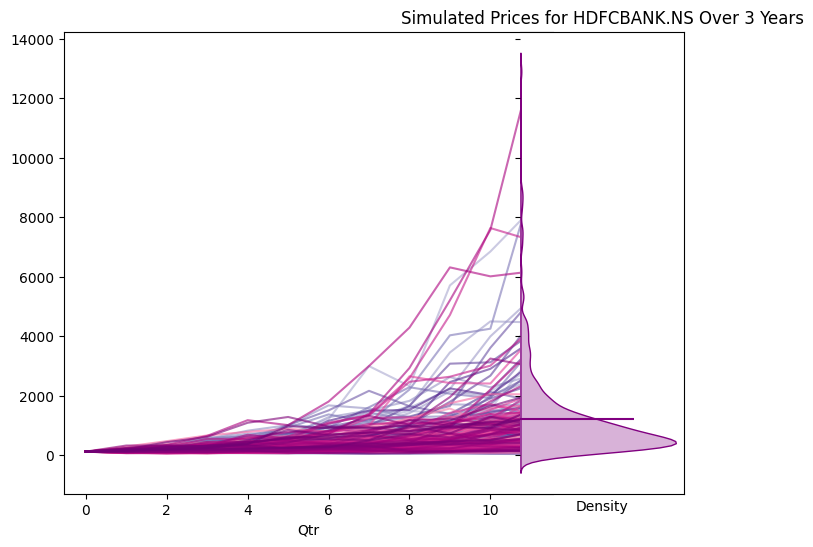

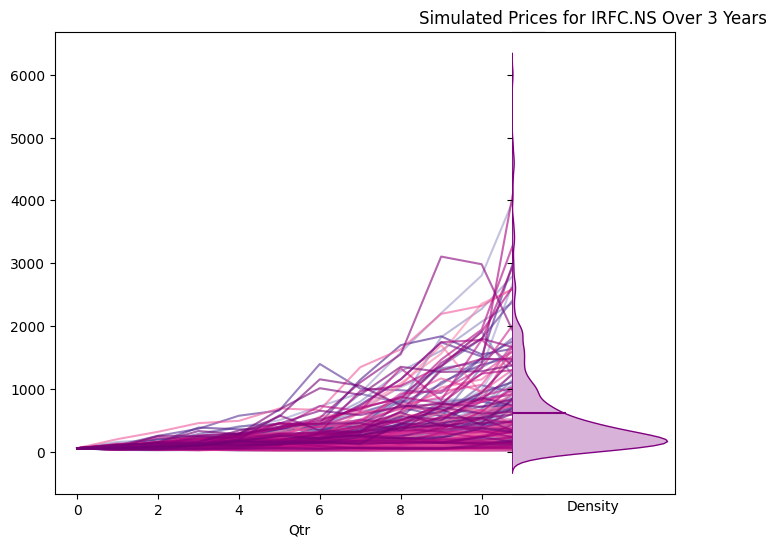

In [32]:
num_lines = 200

# colors = cm.Purples(np.linspace(0.4, 0.9, num_lines))
colors_purple = [cm.Purples(i) for i in np.linspace(0.4, 0.9, num_lines // 2)]
colors_pink = [cm.RdPu(i) for i in np.linspace(0.4, 0.9, num_lines // 2)]
colors = colors_purple + colors_pink

for i, s in enumerate(stocks):
    # plt.figure(figsize=(10,5))
    # fig, ax1 = plt.subplots(figsize=(10, 5))
    fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True, figsize=(8, 6), gridspec_kw={'width_ratios': [3, 1]})
    # Remove borders between subplots
    plt.subplots_adjust(wspace=-0.1)

    for line_n in range(num_lines):
        ax1.plot(paths[:, i, line_n], color=colors[line_n], alpha=0.6)  # First 10 gold simulations
    
    ax1.spines['right'].set_visible(False) 
    ax1.set_xlabel("Qtr")
    # xaxis
    
    # ax2 = ax1.twiny()
    # fig, ax2 = plt.subplots(figsize=(10, 5))
    sns.kdeplot(y=y_final_values[:, i, :500][0], ax=ax2, color='purple', fill=True, alpha=0.3, bw_adjust=0.5)
    # Adjust x-limits so KDE starts after line plot
    ax2.spines['left'].set_visible(False)
    ax2.hlines(y_final_values[:, i, :500][0].mean(), 0, 0.0005, color='purple')
    ax2.set_xticks([])

    plt.title(f"Simulated Prices for {s} Over 3 Years")
    # plt.xlabel("Days")
    plt.ylabel("Price")
    plt.show()

In [75]:
ax2.get_ylim()

(np.float64(-341.56431176100836), np.float64(4094.099782246115))

In [31]:
colors

array([[0.71372549, 0.71372549, 0.84705882, 1.        ],
       [0.68788927, 0.68358324, 0.82983468, 1.        ],
       [0.66574394, 0.65774702, 0.81507113, 1.        ],
       [0.63990773, 0.62760477, 0.79784698, 1.        ],
       [0.61407151, 0.59856978, 0.7817301 , 1.        ],
       [0.58823529, 0.57359477, 0.7696732 , 1.        ],
       [0.56608997, 0.55218762, 0.75933872, 1.        ],
       [0.54025375, 0.52721261, 0.74728181, 1.        ],
       [0.51441753, 0.5022376 , 0.73522491, 1.        ],
       [0.49214917, 0.47057286, 0.71915417, 1.        ],
       [0.47590927, 0.43809304, 0.70217609, 1.        ],
       [0.45696271, 0.40019992, 0.68236832, 1.        ],
       [0.43801615, 0.36230681, 0.66256055, 1.        ],
       [0.42177624, 0.32982699, 0.64558247, 1.        ],
       [0.40282968, 0.29310265, 0.62752787, 1.        ],
       [0.38388312, 0.25693195, 0.61030373, 1.        ],
       [0.36493656, 0.22076125, 0.59307958, 1.        ],
       [0.34869666, 0.18975779,

In [41]:
num_rows = len(portfolio)

In [43]:
date_index = pd.date_range(start=pd.Timestamp.today().date(), periods=num_rows, freq='90D')
formatted_index = date_index.strftime("%b-%Y")
portfolio.index = formatted_index

In [ ]:
def plot_mc_gbm(df):
    num_lines = 50

    # colors = cm.Purples(np.linspace(0.4, 0.9, num_lines))
    colors_purple = [cm.Purples(i) for i in np.linspace(0.4, 0.9, num_lines // 2)]
    colors_pink = [cm.RdPu(i) for i in np.linspace(0.4, 0.9, num_lines // 2)]
    colors = colors_purple + colors_pink

    fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True, figsize=(8, 6), gridspec_kw={'width_ratios': [3, 1]})
    # Remove borders between subplots
    plt.subplots_adjust(wspace=-0.1)

    for line_n in range(num_lines):
        ax1.plot(df.iloc[:, line_n], color=colors[line_n], alpha=0.6)  # First 10 gold simulations
    
    ax1.spines['right'].set_visible(False) 
    ax1.set_xlabel("Qtr")
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

    sns.kdeplot(y=df.iloc[-1, :num_lines], ax=ax2, color='purple', fill=True, alpha=0.3, bw_adjust=0.5)
    # Adjust x-limits so KDE starts after line plot
    ax2.spines['left'].set_visible(False)
    # ax2.hlines(df.iloc[:, -1].mean(), 0, 0.0005, color='purple')
    ax2.set_xticks([])

    plt.title(f"Quarterly Simulated Prices for Portfolio")
    # plt.xlabel("Days")
    plt.ylabel("Price")
    
    return fig 

In [45]:
portfolio.iloc[:, 0]

Mar-2025    1761.179977
Jun-2025    1903.219728
Sep-2025    2002.551983
Dec-2025    1930.262369
Mar-2026    1997.180103
Jun-2026    2240.254372
Sep-2026    2635.723852
Dec-2026    2707.394938
Mar-2027    2861.366879
Jun-2027    3267.443123
Aug-2027    3672.306523
Nov-2027    4465.451952
Name: 0, dtype: float64

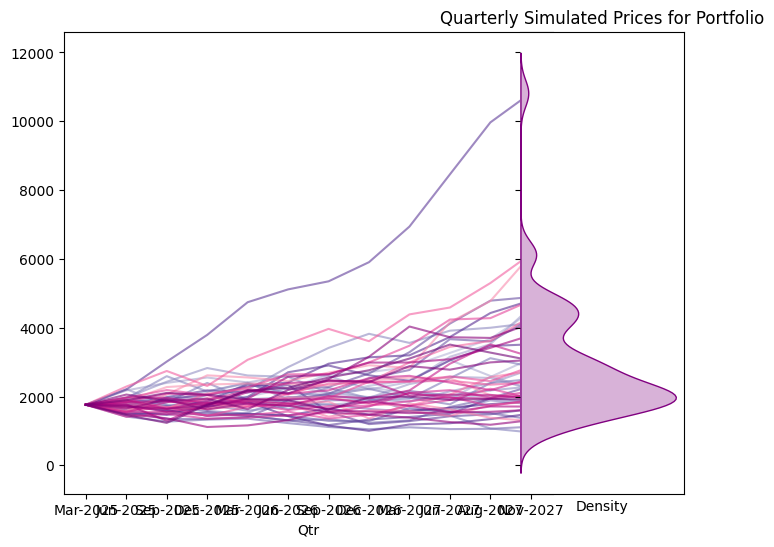

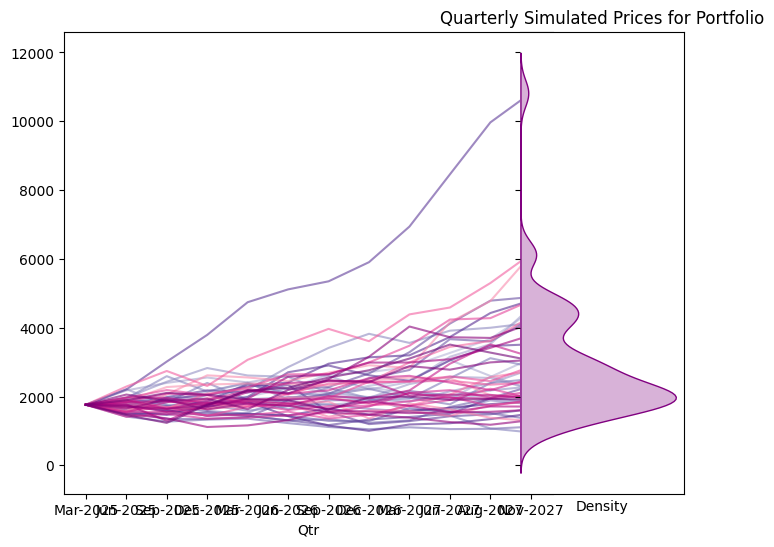

In [46]:
plot_mc_gbm(portfolio)